# **Final Notebook: Handcrafted Window Features**

In [2]:
#imports
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if os.getcwd().endswith("notebooks_final"):
    os.chdir("../")
from src_final.features.local_feature_extractor import WindowFeatureExtractor
from src_final.features.aggregation import aggregate_window_features
from src_final.models.analysis import leakage_free_residual_analysis
from src_final.models.baseline_loso import evaluate_loso_model

In [3]:
processed_path = "data/processed/landmark_dataframes/"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("30fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

# load df with where first column in csv serves as index
df_vid_name_map = pd.read_csv("data/scores/vid_name_map.csv", index_col=0)

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_30fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        participant_id = df_vid_name_map.loc[vid]['Participant Number']
        if int(participant_id) == 8:
            continue
        df_dict[(vid, int(participant_id))] = pd.read_pickle(path)#[cols_to_keep]
        pbar.update(1)

df_dict = dict(sorted(df_dict.items()))

df_scores = pd.read_csv("data/scores/merged_scores.csv")[['Vid_Name', 'QRS_Overal']]
grs_scores = df_scores.set_index('Vid_Name')['QRS_Overal'].to_dict()

Loading processed data:  97%|█████████▋| 83/86 [00:03<00:00, 27.19it/s]


In [4]:
# 1. Initialize and Prepare Data
extractor = WindowFeatureExtractor(hand="Right", window_sec=1.5, step_sec=0.5, log_transform=True, include_bimanual=False)
df_window_features = extractor.extract_features(df_dict)

Extracting Right Features: 100%|██████████| 83/83 [00:32<00:00,  2.54it/s]


In [5]:
feature_cols = [col for col in df_window_features.columns if col not in ['video_id', 'window_start_frame']]

# !!!might want to apply a log transform prior to video level aggregation to some more features!!!
df_window_features[feature_cols].describe()

,total_path,is_idle,path_ratio,curvature,vel_mean,vel_p90,spatial_spread,dim_jerk,ang_vel_mean,ang_vel_std,palm_area_cv
count,66805.000000,66805.00000,66805.000000,66805.000000,66805.000000,66805.000000,66805.000000,66805.000000,66805.000000,66805.000000,66805.000000
mean,158.748090,0.03139,1.519776,0.460667,103.996835,208.313398,2.828038,-10.329352,0.666374,0.936019,0.264347
std,146.390429,0.17437,0.709494,0.363143,96.484890,213.852577,0.982580,0.992852,0.848246,1.488702,0.248197
min,3.876668,0.00000,0.697844,0.000000,2.350377,3.933553,0.246734,-13.357654,0.012433,0.015308,0.002284
25%,51.629718,0.00000,0.977362,0.177502,33.626123,63.795117,2.159423,-11.057366,0.141644,0.168370,0.052784
50%,113.647418,0.00000,1.305871,0.366193,74.410062,143.554576,2.833537,-10.422692,0.365893,0.448227,0.173780
75%,220.021096,0.00000,1.877526,0.663158,143.870460,273.595858,3.419564,-9.689699,0.837948,1.047698,0.444270
max,1311.611813,1.00000,6.529262,6.916799,858.641543,2278.791896,5.928947,-5.919160,12.414626,18.612265,1.751071


In [6]:
# Usage
df_window_features['is_idle'] = (df_window_features['total_path'] < 15).astype(int)
df_agg = aggregate_window_features(df_window_features, p=80)

In [7]:
df_agg.describe()

,idle_prop,idle_switch_count,vel_mean_median,vel_mean_std,vel_mean_p90,vel_p90_median,vel_p90_std,vel_p90_p90,spatial_spread_median,spatial_spread_std,...,curvature_p90,curvature_max,path_ratio_median,path_ratio_std,path_ratio_p90,path_ratio_max,palm_area_cv_median,palm_area_cv_std,palm_area_cv_p90,palm_area_cv_max
count,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,...,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000
mean,0.032957,25.265060,84.448094,95.168073,168.927313,161.470735,214.036823,318.725645,2.853740,0.923980,...,0.706620,2.222855,1.343350,0.719116,2.092744,5.021931,0.221636,0.243035,0.504423,1.283573
std,0.025922,21.001791,25.151202,14.596162,39.180845,46.848427,34.011149,66.992860,0.191141,0.065478,...,0.077899,0.823549,0.143961,0.091179,0.246330,0.572634,0.094940,0.026308,0.095761,0.189665
min,0.000000,0.000000,41.835878,65.534445,99.817988,78.516250,145.836856,191.037411,2.401931,0.765602,...,0.511519,1.232203,1.158384,0.552887,1.720576,3.937255,0.087561,0.159462,0.231842,0.886022
25%,0.012917,9.000000,67.253044,84.565112,140.222962,132.646520,196.369629,275.570796,2.727818,0.871441,...,0.654198,1.706257,1.243995,0.652560,1.911908,4.634484,0.146910,0.229955,0.435436,1.145114
50%,0.026764,21.000000,78.660127,94.150408,164.083070,153.545122,211.554741,308.538011,2.854649,0.923912,...,0.702916,2.004935,1.306920,0.705987,2.036871,4.978258,0.199738,0.241495,0.522013,1.271161
75%,0.044272,34.000000,96.017684,104.126510,191.368448,183.871272,237.316904,368.023833,2.978134,0.967478,...,0.763763,2.502461,1.428873,0.777968,2.247010,5.301607,0.291138,0.262749,0.580762,1.394251
max,0.126354,115.000000,168.586085,140.226736,295.782386,364.249817,312.980212,506.845187,3.433514,1.061156,...,0.880950,6.916799,1.741219,0.964100,2.743636,6.529262,0.463195,0.296389,0.658279,1.751071


In [6]:
df_agg.head()

,video_id,idle_prop,idle_switch_count,vel_mean_median,vel_mean_std,vel_mean_p90,vel_p90_median,vel_p90_std,vel_p90_p90,spatial_spread_median,...,curvature_p90,curvature_max,path_ratio_median,path_ratio_std,path_ratio_p90,path_ratio_max,palm_area_cv_median,palm_area_cv_std,palm_area_cv_p90,palm_area_cv_max
0,"(2024-01-15_13-18-23, 1)",0.003974,3,97.077882,98.782169,174.534659,193.455665,239.360684,315.124352,3.059080,...,0.604732,2.343343,1.217364,0.637203,1.925558,4.005544,0.144251,0.251164,0.489753,1.392011
1,"(2024-01-15_13-37-36, 1)",0.013021,5,62.781441,96.039829,163.703066,138.768882,234.608797,323.724540,2.806285,...,0.646107,1.587495,1.236898,0.657416,1.799842,3.937255,0.104430,0.252009,0.433258,1.560182
2,"(2024-01-15_14-03-23, 1)",0.027697,19,128.424091,91.392593,175.714671,217.485636,211.554741,319.181322,2.919845,...,0.599434,2.969896,1.493189,0.795159,2.371844,4.809025,0.331549,0.287952,0.658279,1.271161
3,"(2024-01-15_14-32-45, 2)",0.017204,32,74.304870,73.019457,135.453489,141.693644,167.855217,245.578760,2.978721,...,0.643372,2.539408,1.252395,0.591918,1.869398,4.972898,0.109867,0.220687,0.364874,1.596058
4,"(2024-01-15_15-05-31, 2)",0.016657,28,53.571254,74.382538,126.245908,101.693975,160.657681,247.804388,2.694071,...,0.731484,1.999376,1.261443,0.552887,1.795768,4.350519,0.104756,0.226598,0.361947,1.297103


In [7]:
from scipy.stats import pearsonr, spearmanr

candidate_features = [col for col in df_agg.columns if col not in ['video_id']]
scores = list(grs_scores.values())

#shuffle scores
import random
#random.seed(42)
#random.shuffle(scores)

feature_df = df_agg[candidate_features]
# compute correlation with scores both pearson and spearman
from scipy.stats import pearsonr, spearmanr
features = list(feature_df.columns)
pearson_corrs = []
spearman_corrs = []
for i in range(feature_df.shape[1]):
    pearson_corr, _ = pearsonr(feature_df.iloc[:, i], scores)
    spearman_corr, _ = spearmanr(feature_df.iloc[:, i], scores)
    pearson_corrs.append(pearson_corr)
    spearman_corrs.append(spearman_corr)

print("Top 15 features by Pearson correlation:")
top_pearson_indices = np.argsort(np.abs(pearson_corrs))[::-1][:15]
for idx in top_pearson_indices:
    print(f"{features[idx]}:        Pearson r = {pearson_corrs[idx]:.4f}, Spearman rho = {spearman_corrs[idx]:.4f}")

Top 15 features by Pearson correlation:
path_ratio_std:        Pearson r = 0.4607, Spearman rho = 0.4748
path_ratio_p90:        Pearson r = 0.4370, Spearman rho = 0.4592
palm_area_cv_median:        Pearson r = 0.3713, Spearman rho = 0.3664
palm_area_cv_p90:        Pearson r = 0.3665, Spearman rho = 0.3763
idle_prop:        Pearson r = 0.3650, Spearman rho = 0.3161
spatial_spread_p90:        Pearson r = -0.3101, Spearman rho = -0.2640
path_ratio_median:        Pearson r = 0.3052, Spearman rho = 0.2795
palm_area_cv_max:        Pearson r = -0.2914, Spearman rho = -0.3030
palm_area_cv_std:        Pearson r = 0.2668, Spearman rho = 0.3230
vel_p90_std:        Pearson r = 0.2203, Spearman rho = 0.2434
spatial_spread_median:        Pearson r = -0.2187, Spearman rho = -0.2654
vel_mean_median:        Pearson r = 0.1707, Spearman rho = 0.1149
curvature_std:        Pearson r = 0.1534, Spearman rho = 0.2539
vel_p90_median:        Pearson r = 0.1380, Spearman rho = 0.0899
vel_mean_std:        Pearso

In [8]:
# load top feature df and combine with aggregated window features
df_top_features = pd.read_csv("data/metrics/top_features_df.csv")
df_combined = pd.merge(df_top_features, df_agg, left_index=True, right_index=True)

In [70]:
top_features = ['num_reversals_Right', 'total_duration_Left', 'nmu_peaks_Right', 'total_path_Right', 'ldlj_smoothness_Left', 'total_angular_path_Right']

candidate_features = [col for col in df_combined.columns if col not in ['Participant Number', 'Case_Number', 'GRS_Total', 'QRS_Overal', 'video_id', 'idle_prop']+top_features]

#candidate_features.remove('velocity_ratio')
df_res_leakage_free = leakage_free_residual_analysis(df_combined, top_features, base_features=['Case_1', 'Case_2', 'Case_3', 'velocity_corr'], candidate_features=candidate_features, top_n=3)
df_res_leakage_free

# - Just observed that spatial spread p80 (idle thresh < 15px and, log transform, and 1.5 sec window) is very strong.

Analyzing Folds: 100%|██████████| 28/28 [00:03<00:00,  8.69it/s]


,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
20,spatial_spread_p90,1.247375e-01,1.262569e-02,9.576665e-02,-0.330830,1.000000
26,vel_p90_p90,9.408601e-02,1.404928e-02,6.522725e-02,-0.249486,1.000000
23,vel_mean_p90,7.786598e-02,1.373678e-02,5.253749e-02,-0.211467,0.964286
19,spatial_spread_median,6.189905e-02,1.133283e-02,3.723352e-02,-0.211553,0.035714
24,vel_mean_std,5.852408e-02,9.559999e-03,4.240193e-02,-0.206772,0.000000
10,idle_switch_count,4.908390e-02,8.344924e-03,2.901141e-02,0.213537,0.000000
21,spatial_spread_std,4.480089e-02,8.968567e-03,2.480100e-02,-0.203425,0.000000
4,ang_vel_mean_p90,3.929542e-02,9.162094e-03,1.566217e-02,-0.168281,0.000000
15,path_ratio_max,3.491005e-02,9.263398e-03,2.273923e-02,0.171589,0.000000
12,palm_area_cv_median,3.247405e-02,7.551082e-03,1.872295e-02,0.124312,0.000000


In [72]:
# top_features intercorrelation
top_candidates = df_res_leakage_free['Feature'].values[:3].tolist()
df_combined[top_candidates+['velocity_corr']].corr()

,spatial_spread_p90,vel_p90_p90,vel_mean_p90,velocity_corr
spatial_spread_p90,1.000000,0.672712,0.548194,-0.297862
vel_p90_p90,0.672712,1.000000,0.951561,-0.406192
vel_mean_p90,0.548194,0.951561,1.000000,-0.347984
velocity_corr,-0.297862,-0.406192,-0.347984,1.000000


In [11]:
# Do the distributions of the top features seem reasonable?
df_agg[top_candidates].describe()

,spatial_spread_p90,palm_area_cv_median
count,83.000000,83.000000
mean,3.607262,0.221636
std,0.191369,0.094940
min,3.123830,0.087561
25%,3.458076,0.146910
50%,3.618852,0.199738
75%,3.711720,0.291138
max,4.011258,0.463195


LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 47.09it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7671 | MAE: 4.9090 | MAE STD: 3.4579 | R2: 0.5838 | Adj R2: 0.5625

Feature Weights:
              Feature  Average_Weight  Std_Weight
0                bias       49.938586    0.302804
1                 PC1       -3.104035    0.077734
2       velocity_corr       -2.933176    0.176200
3  spatial_spread_p90       -2.355915    0.135582

--- Per-Fold Performance Summary ---
    Train_MAE  Test_MAE  Test_Corr
1    4.431869  7.584332  -0.453162
2    4.618634  3.129014   0.863770
3    4.529109  6.705278   0.991321
4    4.498859  5.743149  -0.177346
5    4.465826  6.612773   0.707909
6    4.584410  4.353698   0.998349
7    4.446781  7.106610  -0.848388
9    4.588746  4.143930  -0.985785
10   4.558957  5.063570   0.064093
11   4.623536  2.751771   0.250405
12   4.585637  3.812302  -0.311947
13   4.638868  2.745744   0.892986
14   4.599180  3.786919   0.790462
15   4.525450  7.532703  -0.322649
16   4.394373  8.929139  -0.658244
17   4.644655  2.2774

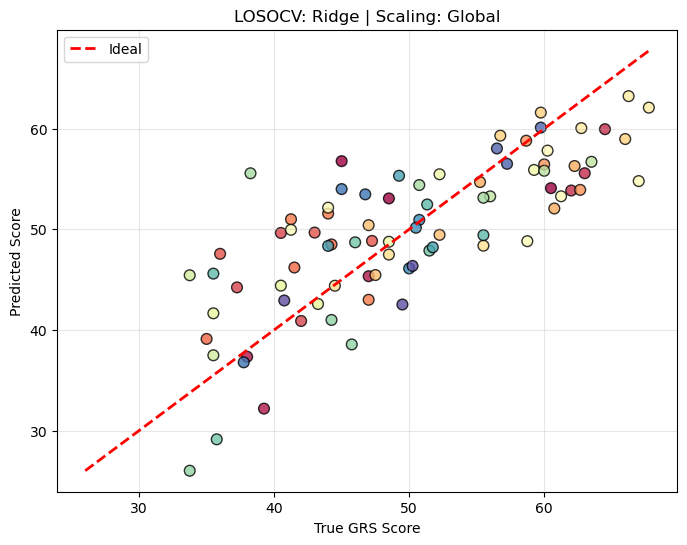

In [ ]:
_, _, _ = evaluate_loso_model(df_combined, top_features, pca_components=[0], extra_features=['velocity_corr']+[top_candidates], print_fold_metrics=True)

# Test Shuffled Residuals

In [13]:
all_shuffled_r2 = []
all_shuffled_p80_spread = []
all_shuffled_parea_cv = []
for seed in range(300):
    df_res = leakage_free_residual_analysis(df_combined, top_features, candidate_features, base_features=['velocity_corr'], top_n=2, perform_shuffle=True, seed=seed)
    top_3_r2 = df_res['Shuffled_R2_mean'].values[:3]
    p80_spread_r2 = df_res[df_res['Feature']=='spatial_spread_p90']['Shuffled_R2_mean'].values[0]
    parea_cv_r2 = df_res[df_res['Feature']=='palm_area_cv_median']['Shuffled_R2_mean'].values[0]
    all_shuffled_p80_spread.append(p80_spread_r2)
    all_shuffled_parea_cv.append(parea_cv_r2)
    print(f"Seed {seed}: Top 3 R2: {top_3_r2}")
    for r2 in top_3_r2:
        all_shuffled_r2.append(r2)

Analyzing Folds: 100%|██████████| 28/28 [00:03<00:00,  7.21it/s]


Seed 0: Top 3 R2: [0.06153539 0.05865471 0.0575256 ]


Analyzing Folds:  96%|█████████▋| 27/28 [00:03<00:00,  7.43it/s]


KeyboardInterrupt: 

Empirical p-value: 0.070
Z-score vs Null: 1.57


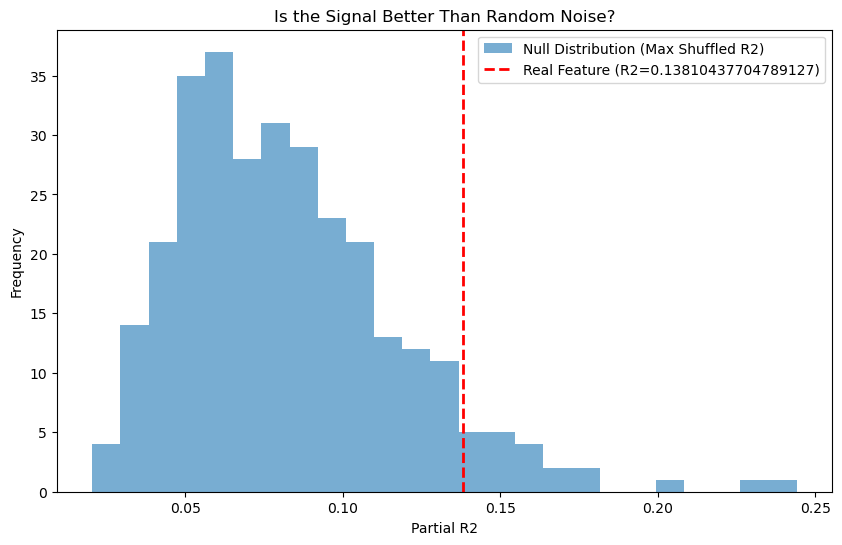

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- DATA INPUT ---
# Your top real feature R2
real_top_r2 = 0.13810437704789127

# Replace this with your actual list of 50 'Max' Shuffled R2 values 
# (The highest R2 observed in each of the 50 shuffle runs)

shuffled_max_r2s = all_shuffled_r2[::3] # your 50 max values

def evaluate_significance(real_val, null_distribution):
    null_distribution = np.array(null_distribution)
    
    # Empirical p-value: what fraction of the null is >= our real signal?
    p_value = np.mean(null_distribution >= real_val)
    
    # Z-score: how many standard deviations is the real signal from the null mean?
    z_score = (real_val - np.mean(null_distribution)) / np.std(null_distribution)
    
    return p_value, z_score

p_val, z_score = evaluate_significance(real_top_r2, shuffled_max_r2s)

print(f"Empirical p-value: {p_val:.3f}")
print(f"Z-score vs Null: {z_score:.2f}")

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.hist(shuffled_max_r2s, bins=25, alpha=0.6, label='Null Distribution (Max Shuffled R2)')
plt.axvline(real_top_r2, color='red', linestyle='--', linewidth=2, label=f'Real Feature (R2={real_top_r2})')
plt.title("Is the Signal Better Than Random Noise?")
plt.xlabel("Partial R2")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Verdict

- The Conservative Choice is to only accept spatial spread p80 as a valid additional feature (reason statistical significance)

- A valid second choice would probably be within fold direct selection of top 2 features, slighly better performance, but likely a bit over optimistic/overfitted


## **MLP Model**


In [1]:
from src_final.models.mlp_regressor import PyTorchMLPEnsemble
from src_final.models.baseline_loso import evaluate_loso_mlp_ensemble

_, _, _ = evaluate_loso_mlp_ensemble(
    model_class=PyTorchMLPEnsemble,
    df=df_combined,
    primary_features=top_features,
    extra_features=['velocity_corr']+['spatial_spread_p90'],
    model_params={'hidden_dim': 12, 'n_hidden': 1, 'n_models': 5, 'dropout': 0.1, 'batch_size': 16},
    pca_components=[0],
    print_fold_metrics=True
)

ModuleNotFoundError: No module named 'src_final'

In [ ]:
candidate_features = [c for c in candidate_features if not c=='path_ratio_p90']

In [ ]:
# one hot encode Case_Number
df_case_onehot = pd.get_dummies(df_combined['Case_Number'], prefix='Case').astype(int)

if not any('Case_1' in col for col in df_combined.columns):
    df_combined = pd.concat([df_combined, df_case_onehot], axis=1)

In [ ]:
from src_final.models.mlp_regressor import PyTorchMLPEnsemble
from src_final.models.baseline_loso import evaluate_loso_mlp_ensemble, run_nested_loso

df_nested_results = run_nested_loso(
    df=df_combined,
    primary_features=top_features,
    candidate_features=candidate_features,
    extra_features=[],
    model_type='mlp',
    model_params={'hidden_dim': 24, 'n_hidden': 2, 'n_models': 5, 'dropout': 0.15, 'batch_size': 16},
    top_n=3,
    print_fold_metrics=True,
    corr_threshold=0.5,
    pr2_threshold=0.04
)

Surgeon 1 | Train MAE: 3.5940 | Test MAE: 5.7549 | Selected Features: ['velocity_corr', 'palm_area_cv_median', 'spatial_spread_p90'] | Selected PR2s: [np.float64(0.1294), np.float64(0.0848), np.float64(0.0616)]
Surgeon 2 | Train MAE: 3.6303 | Test MAE: 2.5312 | Selected Features: ['velocity_corr', 'palm_area_cv_median', 'spatial_spread_p90'] | Selected PR2s: [np.float64(0.1234), np.float64(0.1164), np.float64(0.0585)]
Surgeon 3 | Train MAE: 3.6947 | Test MAE: 5.9426 | Selected Features: ['palm_area_cv_median', 'velocity_corr', 'spatial_spread_p90'] | Selected PR2s: [np.float64(0.1081), np.float64(0.0973), np.float64(0.0852)]
Surgeon 4 | Train MAE: 3.6238 | Test MAE: 4.9828 | Selected Features: ['velocity_corr', 'palm_area_cv_median', 'spatial_spread_p90'] | Selected PR2s: [np.float64(0.1385), np.float64(0.1017), np.float64(0.0455)]
Surgeon 5 | Train MAE: 3.7339 | Test MAE: 6.3334 | Selected Features: ['velocity_corr', 'palm_area_cv_median', 'spatial_spread_p90'] | Selected PR2s: [np.fl

=== Nested LOSO Summary (mlp) ===
MAE: 4.6710 +/- 3.6431
Train MAE: 4.6710
Spearman R: 0.7626

Feature Selection Stability:
spatial_spread_p90    1.0


24 neurons
=== Nested LOSO Summary (mlp) ===
MAE: 4.6414 +/- 3.6030
Train MAE: 4.6414
Spearman R: 0.7655

Feature Selection Stability:
spatial_spread_p90    1.0
Name: count, dtype: float64



no extra features, ridge, 
    top_n=3,
    print_fold_metrics=True,
    corr_threshold=0.5,
    pr2_threshold=0.04


=== Nested LOSO Summary (ridge) ===
MAE: 4.8749 +/- 3.5119
Train MAE: 4.8749
Spearman R: 0.7701

Feature Selection Stability:
velocity_corr          1.000000
spatial_spread_p90     1.000000
palm_area_cv_median    0.857143
path_ratio_p90         0.142857
Name: count, dtype: float64

You are completely right to be cautious here. Your "gut feeling" about the randomness and the "manual overfitting" is actually a very high-level data science intuition.

If you go down the "Final Boss" path, you aren't just building a model; you are building a house of cards. Here is why you should probably stick to the Ridge-based residual model for your formal results.

1. The Variance Cascade (The "Messiness")

When you train a model on the residuals of another stochastic model (an ensemble MLP), you are compounding the variance.

Layer 1: The MLP ensemble has a certain "noise" based on its random seeds.

Layer 2: Your MIL model is now trying to learn a signal from that noise.

In a LOSO (Leave-One-Out) setup with N=84, if one fold's MLP initialization is slightly "off," it will produce weird residuals that will cause the MIL in that fold to go down a rabbit hole. You would end up with results that are very hard to replicate, which is a red flag for a thesis.

2. The "Honest Overfitting" Admission

You mentioned you manually played with the MLP hyperparameters to hit that 4.63. In the ML world, we call this "Leakage by Human Iteration." Because you (the researcher) saw the test results and went back to tweak the model to improve them, those test results are no longer truly "unseen."

The Ridge Baseline is the "Adult in the Room": Because Ridge regression is a convex optimization problem, it has a single global solution. It doesn't care about random seeds. By using Ridge as your baseline, you provide a stable, objective floor. Any improvement the MIL makes over the Ridge is "cleaner" and more scientifically valid than squeezing a few extra points out of a manually-tuned MLP.

3. The "Case ID" Confounder

This is the most important part: Your MLP (4.63) used Case_1, 2, 3. Your MIL (4.74) did not.

Case variables are essentially a "cheat code"—they tell the model the task difficulty.

If you want to see if your MIL is actually better, you should add Case_1, 2, 3 to your Ridge baseline first.

My Recommendation for Your Thesis Strategy

Instead of chasing the "Final Boss" (which is statistically shaky), I would present your work in this hierarchy:

The "Standard" Baseline: Ridge (Global Features).

The "Movement Insight" Model: Your Residual MIL (4.74). This is your main contribution because it finds local kinematic signals.

The "Ablation" Note: You can mention in a single paragraph that "A manually tuned global MLP reached 4.63, suggesting that non-linearities in global metrics and task-specific biases (Case IDs) are significant, but lack the local interpretability provided by the MIL approach."

Why this is a "Safe" Win

By choosing the 4.74 model as your "hero," you are choosing Methodology over Leaderboards. * A 4.63 result that is "manually overfitted" is hard to defend in a viva/defense.

A 4.74 result that follows a strict, stable, residual-based pipeline with attention-based local insights is bulletproof.

## **BoW**

**Need to scale features before k-means clustering**

- First do it with a little data leakage
- But for the final results need to do this within each fold!

In [ ]:
# 1. Initialize and Prepare Data
extractor = WindowFeatureExtractor(hand="Right", window_sec=1.5, step_sec=0.5, log_transform=False, include_bimanual=False)
df_window_features = extractor.extract_features(df_dict)

Extracting Right Features: 100%|██████████| 83/83 [00:56<00:00,  1.46it/s]


In [ ]:
from sklearn.preprocessing import RobustScaler, StandardScaler, QuantileTransformer, PowerTransformer
import numpy as np

def prepare_clustering_data(df_windows, feature_cols, method='log', clip=5.0):
    """
    Prepares kinematic data for K-Means clustering.
    
    Methods:
        'log': Original np.log1p approach.
        'sqrt': Square root transform (medium-strength tail compression).
        'quantile': Forces a uniform or normal distribution (removes skew entirely).
        'yeo-johnson': Parametric power transform to minimize skewness.
    """
    X = df_windows[feature_cols].copy()
    
    # Identify skewed targets
    skew_targets = [c for c in feature_cols if any(x == c for x in ['dim_jerk', 'curvature', 'path_ratio', 'spatial_spread', 'vel_mean', 'palm_area_cv', 'ang_vel_mean'])]
    
    # 1. Apply Primary Transform
    if method == 'log':
        for col in skew_targets:
            X[col] = np.log1p(X[col])
    elif method == 'sqrt':
        for col in skew_targets:
            X[col] = np.sqrt(np.abs(X[col]))
    elif method == 'quantile':
        # output_distribution='normal' makes it easier for K-means to find spherical blobs
        qt = QuantileTransformer(output_distribution='normal', n_quantiles=100, random_state=42)
        X[skew_targets] = qt.fit_transform(X[skew_targets])
    elif method == 'yeo-johnson':
        pt = PowerTransformer(method='yeo-johnson')
        X[skew_targets] = pt.fit_transform(X[skew_targets])

    # 2. Scaling
    # Using RobustScaler followed by StandardScaler is the "gold standard" for K-means
    # as it centers the data while remaining resistant to extreme window artifacts.
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 3. Clipping
    # A clip of 10.0 is very wide for a Z-scored distribution (10 standard deviations).
    # Standard practice is usually 3.0 or 5.0 to ensure outliers don't pull centroids.
    X_scaled = np.clip(X_scaled, -clip, clip)
    
    return X_scaled, scaler


In [ ]:
clip = 5.0
with_idle = False

if not with_idle:
    df = df_window_features[df_window_features['is_idle'] == 0].copy()
else:
    df = df_window_features.copy()

In [ ]:
df_window_features.describe()

,total_path,is_idle,path_ratio,curvature,vel_mean,vel_p90,spatial_spread,dim_jerk,ang_vel_mean,ang_vel_std,palm_area_cv,window_start_frame
count,66805.000000,66805.00000,66805.000000,66805.000000,66805.000000,66805.000000,66805.000000,66805.000000,66805.000000,66805.000000,66805.000000,66805.000000
mean,158.748090,0.03139,5.593937,0.460667,103.996835,208.313398,26.701205,46693.146149,0.666374,0.936019,0.264347,9929.997859
std,146.390429,0.17437,11.842887,0.363143,96.484890,213.852577,33.447463,43279.488706,0.848246,1.488702,0.248197,6974.861681
min,3.876668,0.00000,1.009416,0.000000,2.350377,3.933553,0.279839,371.098917,0.012433,0.015308,0.002284,1.000000
25%,51.629718,0.00000,1.657437,0.177502,33.626123,63.795117,7.666133,16149.388137,0.141644,0.168370,0.052784,4517.000000
50%,113.647418,0.00000,2.690903,0.366193,74.410062,143.554576,16.005497,33612.790053,0.365893,0.448227,0.173780,8939.000000
75%,220.021096,0.00000,5.537311,0.663158,143.870460,273.595858,29.556090,63408.281208,0.837948,1.047698,0.444270,13882.000000
max,1311.611813,1.00000,683.892277,6.916799,858.641543,2278.791896,374.758455,632637.246792,12.414626,18.612265,1.751071,38421.000000


In [ ]:
feature_cols = [col for col in df_window_features.columns if col not in ['video_id', 'window_start_frame']]

# Workflow
clustering_features = [col for col in df_window_features.columns if col in ['dim_jerk', 'curvature', 'path_ratio', 'spatial_spread', 'vel_mean', 'palm_area_cv', 'ang_vel_mean']]
X_for_km, scaler = prepare_clustering_data(df, clustering_features, method='log', clip=5)
pd.DataFrame(X_for_km, columns=clustering_features).describe()

,path_ratio,curvature,vel_mean,spatial_spread,dim_jerk,ang_vel_mean,palm_area_cv
count,64708.000000,64708.000000,6.470800e+04,6.470800e+04,6.470800e+04,64708.000000,6.470800e+04
mean,-0.000430,-0.000243,4.497718e-16,4.567994e-16,2.459689e-16,-0.000053,3.689534e-17
std,0.997613,0.998568,1.000008e+00,1.000008e+00,1.000008e+00,0.999734,1.000008e+00
min,-1.150110,-1.538830,-2.387124e+00,-2.452764e+00,-4.448141e+00,-1.123650,-1.200721e+00
25%,-0.767828,-0.823297,-7.462944e-01,-6.975576e-01,-6.449578e-01,-0.779282,-8.989379e-01
50%,-0.306322,-0.173564,6.224454e-02,-2.349847e-02,9.612538e-02,-0.302067,-2.864060e-01
75%,0.511058,0.678681,7.627216e-01,5.961783e-01,7.288259e-01,0.487719,8.209401e-01
max,5.000000,5.000000,2.708751e+00,3.251688e+00,3.115685e+00,5.000000,4.290167e+00


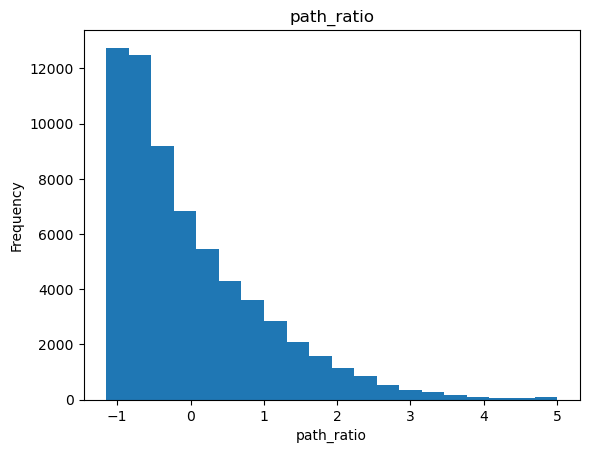

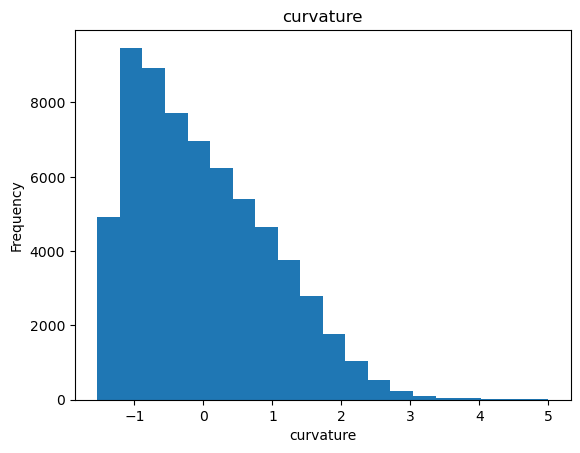

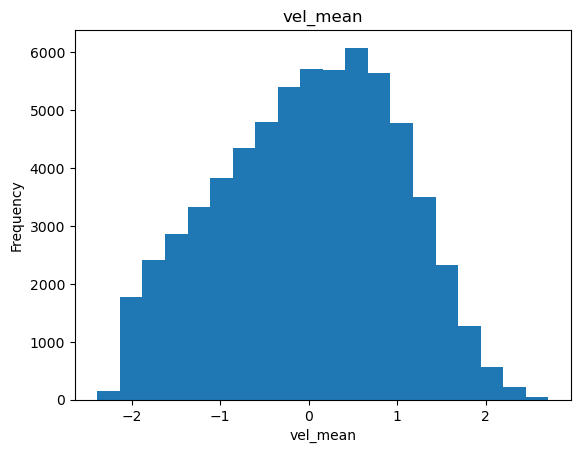

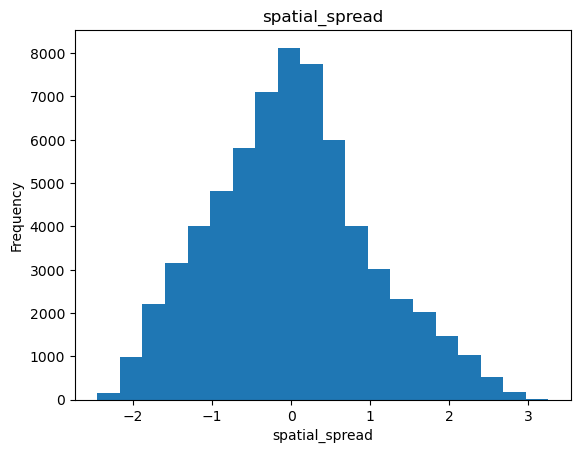

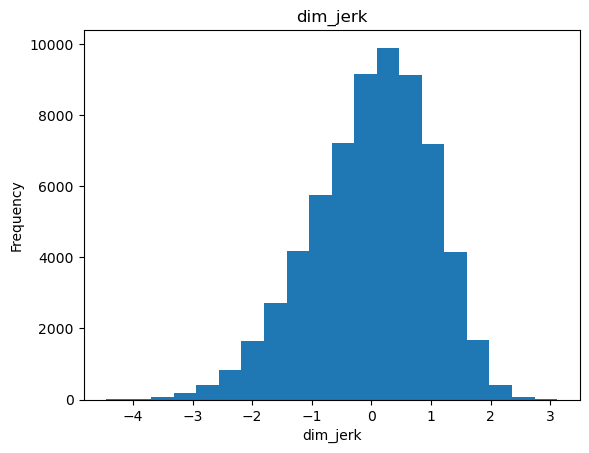

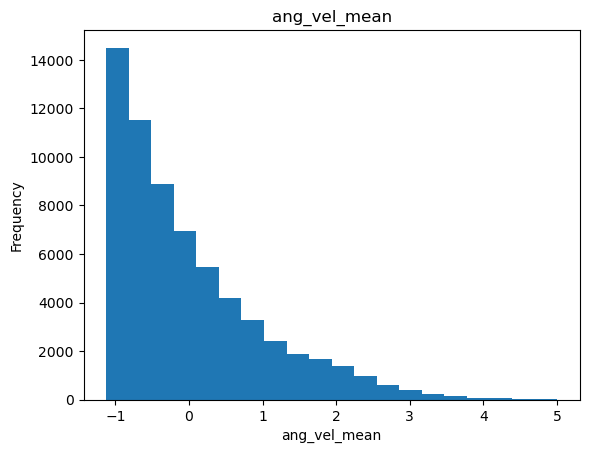

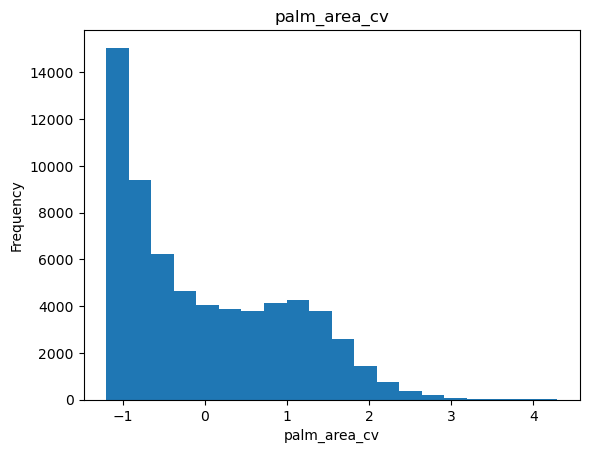

In [ ]:
import matplotlib.pyplot as plt

for feat in clustering_features:
    plt.figure()
    pd.DataFrame(X_for_km, columns=clustering_features)[feat].plot(kind='hist', bins=20)
    plt.title(feat)
    plt.xlabel(feat)
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
# to move elsewhere later as function
from sklearn.cluster import MiniBatchKMeans

N_CLUSTERS = 16
RANDOM_STATE = 42
N_INIT = 5
METHOD = 'log'
skew_targets = [c for c in clustering_features if any(x == c for x in ['dim_jerk', 'curvature', 'path_ratio', 'spatial_spread', 'vel_mean', 'palm_area_cv_mean', 'ang_vel_mean'])]

kmeans = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=N_INIT)
kmeans.fit(X_for_km)

bow_features = []

for vid, group in df.groupby('video_id'):
    
    X = group[clustering_features].copy()
    # 1. Apply Primary Transform
    if METHOD == 'log':
        for col in skew_targets:
            X[col] = np.log1p(X[col])
    elif METHOD == 'sqrt':
        for col in skew_targets:
            X[col] = np.sqrt(np.abs(X[col]))
    elif METHOD == 'quantile':
        # output_distribution='normal' makes it easier for K-means to find spherical blobs
        qt = QuantileTransformer(output_distribution='normal', n_quantiles=100, random_state=42)
        X[skew_targets] = qt.fit_transform(X[skew_targets])
    elif METHOD == 'yeo-johnson':
        pt = PowerTransformer(method='yeo-johnson')
        X[skew_targets] = pt.fit_transform(X[skew_targets])

    X_vid =  scaler.transform(X)
    X_vid = np.clip(X_vid, -clip, clip)
    cluster_labels = kmeans.predict(X_vid)
    
    # Build histogram
    hist, _ = np.histogram(cluster_labels, bins=np.arange(N_CLUSTERS + 1))
    hist = hist / np.sum(hist)  # Normalize to get proportions
    
    bow_features.append((vid, hist))

col_names = [f'BoW_{i}' for i in range(N_CLUSTERS)]
bow_df = pd.DataFrame([x[1] for x in bow_features], columns=col_names)  
bow_df['video_id'] = [x[0] for x in bow_features]   

bow_df[[col for col in bow_df.columns if col != 'video_id']].describe()

,BoW_0,BoW_1,BoW_2,BoW_3,BoW_4,BoW_5,BoW_6,BoW_7,BoW_8,BoW_9,BoW_10,BoW_11,BoW_12,BoW_13,BoW_14,BoW_15
count,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000
mean,0.078272,0.073973,0.050588,0.056709,0.066479,0.048382,0.054388,0.118148,0.100238,0.028218,0.062949,0.047455,0.070515,0.052297,0.049595,0.041795
std,0.022359,0.036575,0.037084,0.018059,0.024300,0.020314,0.024314,0.061247,0.038095,0.025314,0.025569,0.028136,0.022385,0.016326,0.042409,0.020603
min,0.039894,0.022099,0.005469,0.019868,0.023013,0.016632,0.012289,0.021907,0.041257,0.000000,0.021505,0.009682,0.025783,0.011364,0.001850,0.003390
25%,0.063429,0.045831,0.024589,0.043839,0.047423,0.033351,0.036519,0.074688,0.072065,0.008777,0.044573,0.026247,0.050830,0.041202,0.016901,0.028739
50%,0.076659,0.069142,0.037313,0.055412,0.068443,0.043933,0.052941,0.104053,0.093439,0.022034,0.059102,0.044199,0.071028,0.051948,0.042528,0.037338
75%,0.094377,0.090013,0.063696,0.068209,0.083391,0.059529,0.070921,0.151567,0.125517,0.042079,0.078805,0.057619,0.086105,0.061391,0.068285,0.052791
max,0.138430,0.194748,0.194260,0.104478,0.123646,0.119701,0.129244,0.343478,0.234828,0.127660,0.138704,0.148760,0.126649,0.094070,0.183956,0.126829


In [ ]:
from scipy.stats import pearsonr, spearmanr

candidate_features = [col for col in bow_df.columns if col not in ['video_id']]
scores = list(grs_scores.values())

#shuffle scores
import random
#random.seed(42)
#random.shuffle(scores)

feature_df = bow_df[candidate_features]
# compute correlation with scores both pearson and spearman
from scipy.stats import pearsonr, spearmanr
features = list(feature_df.columns)
pearson_corrs = []
spearman_corrs = []
for i in range(feature_df.shape[1]):
    pearson_corr, _ = pearsonr(feature_df.iloc[:, i], scores)
    spearman_corr, _ = spearmanr(feature_df.iloc[:, i], scores)
    pearson_corrs.append(pearson_corr)
    spearman_corrs.append(spearman_corr)

print("Top 10 features by Pearson correlation:")
top_pearson_indices = np.argsort(np.abs(pearson_corrs))[::-1][:12]
for idx in top_pearson_indices:
    print(f"{features[idx]}:        Pearson r = {pearson_corrs[idx]:.4f}, Spearman rho = {spearman_corrs[idx]:.4f}")

Top 10 features by Pearson correlation:
BoW_1:        Pearson r = -0.4481, Spearman rho = -0.4342
BoW_2:        Pearson r = 0.3950, Spearman rho = 0.4338
BoW_7:        Pearson r = 0.3542, Spearman rho = 0.3198
BoW_3:        Pearson r = -0.2950, Spearman rho = -0.2735
BoW_8:        Pearson r = -0.2465, Spearman rho = -0.2269
BoW_4:        Pearson r = -0.2380, Spearman rho = -0.2171
BoW_10:        Pearson r = -0.2133, Spearman rho = -0.1456
BoW_9:        Pearson r = 0.1914, Spearman rho = 0.0906
BoW_15:        Pearson r = 0.1832, Spearman rho = 0.1338
BoW_12:        Pearson r = -0.1683, Spearman rho = -0.1593
BoW_5:        Pearson r = -0.1635, Spearman rho = -0.1850
BoW_0:        Pearson r = 0.1128, Spearman rho = 0.0995


In [ ]:
# check cluster centroids for top positive and negative predictors
top_2_positive = np.argsort(pearson_corrs)[-5:]
top_2_negative = np.argsort(pearson_corrs)[:5]
centroids = kmeans.cluster_centers_
feature_names = clustering_features

print("--- Negative Predictors (Novice Moves) ---")
for idx in top_2_negative:
    print(f"Cluster {idx}, (corr: {round(pearson_corrs[idx], 3)}): {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

print("\n--- Positive Predictors (Expert Moves) ---")
for idx in reversed(top_2_positive):
    print(f"Cluster {idx}, (corr: {round(pearson_corrs[idx], 3)}): {dict(zip(feature_names, np.round(centroids[idx], 2)))}")

--- Negative Predictors (Novice Moves) ---
Cluster 1, (corr: -0.448): {'path_ratio': np.float64(-0.51), 'curvature': np.float64(-0.67), 'vel_mean': np.float64(0.07), 'spatial_spread': np.float64(0.31), 'dim_jerk': np.float64(-0.3), 'ang_vel_mean': np.float64(-0.48), 'palm_area_cv': np.float64(-0.53)}
Cluster 3, (corr: -0.295): {'path_ratio': np.float64(-0.58), 'curvature': np.float64(-0.33), 'vel_mean': np.float64(0.56), 'spatial_spread': np.float64(0.78), 'dim_jerk': np.float64(-0.44), 'ang_vel_mean': np.float64(0.54), 'palm_area_cv': np.float64(0.57)}
Cluster 8, (corr: -0.247): {'path_ratio': np.float64(-0.32), 'curvature': np.float64(0.54), 'vel_mean': np.float64(-1.05), 'spatial_spread': np.float64(-0.88), 'dim_jerk': np.float64(0.1), 'ang_vel_mean': np.float64(-0.84), 'palm_area_cv': np.float64(-0.92)}
Cluster 4, (corr: -0.238): {'path_ratio': np.float64(-0.26), 'curvature': np.float64(0.19), 'vel_mean': np.float64(-0.41), 'spatial_spread': np.float64(-0.37), 'dim_jerk': np.float6

In [ ]:
# load top feature df and combine with aggregated window features
comb_df = pd.merge(df_top_features, bow_df, left_index=True, right_index=True)

#candidate_features = [c for c in candidate_features if c not in ['palm_area_cv_p10', 'palm_area_cv_p90', 'palm_area_cv_mean', 'palm_area_cv_std', 'is_idle_p90', 'is_idle_std', 'is_idle_median', 'is_idle_p10']]
df_res_leakage_free = leakage_free_residual_analysis(comb_df, top_features, candidate_features, base_features=['velocity_corr'], top_n=1, perform_shuffle=False)
df_res_leakage_free

Analyzing Folds: 100%|██████████| 28/28 [00:02<00:00,  9.85it/s]


,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
13,BoW_7,0.104637,0.009323,8.081731e-02,0.317312,1.0
1,BoW_1,0.041257,0.009084,2.768238e-02,-0.181559,0.0
8,BoW_2,0.036395,0.006049,2.306607e-02,0.172804,0.0
2,BoW_10,0.030918,0.009556,1.379675e-02,-0.172258,0.0
11,BoW_5,0.028184,0.006372,1.327106e-02,-0.153503,0.0
7,BoW_15,0.026617,0.006597,1.520614e-02,0.158768,0.0
5,BoW_13,0.025129,0.007318,1.018748e-02,-0.149877,0.0
14,BoW_8,0.021162,0.008161,9.526487e-04,-0.137047,0.0
4,BoW_12,0.020039,0.006767,2.353519e-03,-0.137450,0.0
15,BoW_9,0.015771,0.006165,6.627881e-03,0.119143,0.0


LOSOCV Folds:   0%|          | 0/28 [00:00<?, ?it/s]

LOSOCV Folds: 100%|██████████| 28/28 [00:00<00:00, 57.80it/s]



=== LOSOCV Results (Global Scaling) ===
R: 0.7497 | MAE: 5.1309 | MAE STD: 3.7812 | R2: 0.5311 | Adj R2: 0.5133

Feature Weights:
         Feature  Average_Weight  Std_Weight
0           bias       49.938586    0.302804
1            PC1       -3.229288    0.071772
2  velocity_corr       -2.316263    0.189529


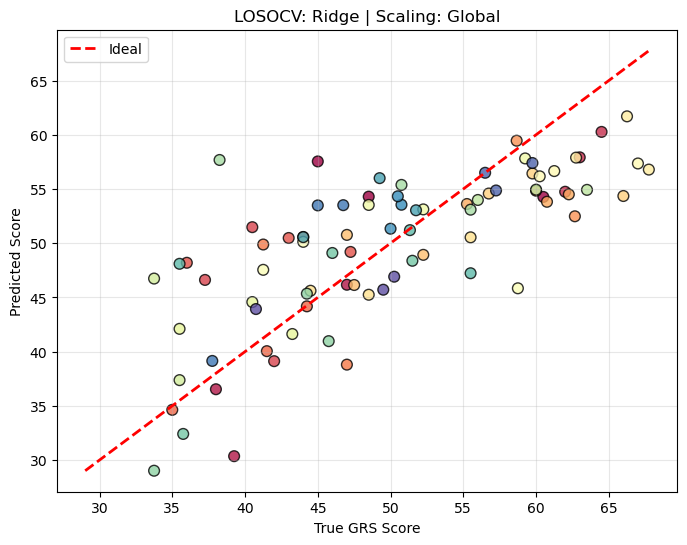

In [ ]:
_, _, _ = evaluate_loso_model(comb_df, top_features, pca_components=[0], extra_features=['velocity_corr'])

### Significance Test 

In [ ]:
all_shuffled_r2 = []
all_shuffled_top_BoW = []

seeds = random.sample(range(0, 100), 25)
for seed in seeds:
    df_res = leakage_free_residual_analysis(comb_df, top_features, candidate_features, base_features=['velocity_corr'], top_n=2, perform_shuffle=True, seed=seed)
    top_3_r2 = df_res['Shuffled_R2_mean'].values[:3]
    bow_6_r2 = df_res[df_res['Feature']=='BoW_7']['Shuffled_R2_mean'].values[0]
    all_shuffled_top_BoW.append(bow_6_r2)
    print(f"Seed {seed}: Top 3 R2: {top_3_r2}")
    for r2 in top_3_r2:
        all_shuffled_r2.append(r2)

Analyzing Folds: 100%|██████████| 28/28 [00:04<00:00,  5.87it/s]


Seed 12: Top 3 R2: [0.04406501 0.04169252 0.03497045]


Analyzing Folds: 100%|██████████| 28/28 [00:05<00:00,  4.85it/s]


Seed 47: Top 3 R2: [0.03420142 0.02730518 0.0225491 ]


Analyzing Folds: 100%|██████████| 28/28 [00:04<00:00,  5.71it/s]


...

Seed 62: Top 3 R2: [0.10098647 0.09899331 0.09154715]


Analyzing Folds: 100%|██████████| 28/28 [00:04<00:00,  6.53it/s]


Seed 61: Top 3 R2: [0.04841938 0.04676928 0.04644585]


Analyzing Folds: 100%|██████████| 28/28 [00:03<00:00,  7.34it/s]

Seed 36: Top 3 R2: [0.15946643 0.14011028 0.13101303]


Empirical p-value: 0.200
Z-score vs Null: 0.71


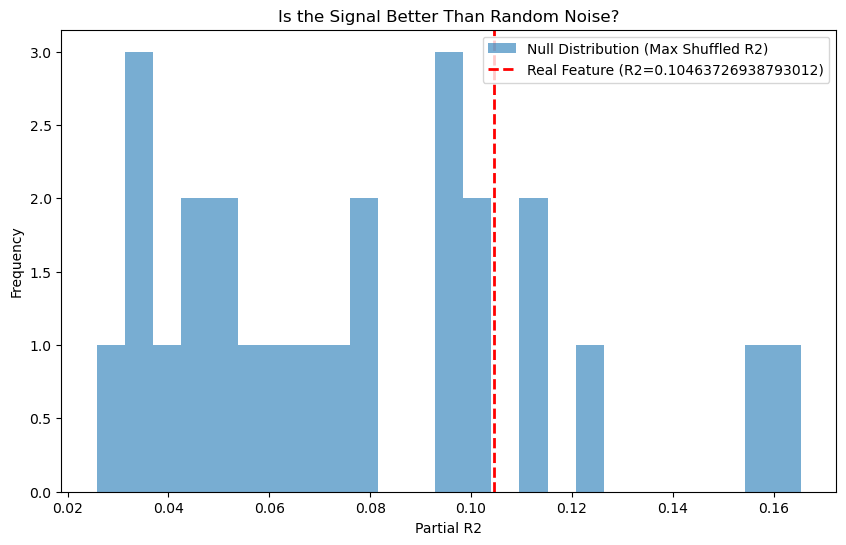

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- DATA INPUT ---
# Your top real feature R2
real_top_r2 = 0.10463726938793012

# Replace this with your actual list of 50 'Max' Shuffled R2 values 
# (The highest R2 observed in each of the 50 shuffle runs)

shuffled_max_r2s = all_shuffled_r2[::3] # your 50 max values

def evaluate_significance(real_val, null_distribution):
    null_distribution = np.array(null_distribution)
    
    # Empirical p-value: what fraction of the null is >= our real signal?
    p_value = np.mean(null_distribution >= real_val)
    
    # Z-score: how many standard deviations is the real signal from the null mean?
    z_score = (real_val - np.mean(null_distribution)) / np.std(null_distribution)
    
    return p_value, z_score

p_val, z_score = evaluate_significance(real_top_r2, shuffled_max_r2s)

print(f"Empirical p-value: {p_val:.3f}")
print(f"Z-score vs Null: {z_score:.2f}")

# --- VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.hist(shuffled_max_r2s, bins=25, alpha=0.6, label='Null Distribution (Max Shuffled R2)')
plt.axvline(real_top_r2, color='red', linestyle='--', linewidth=2, label=f'Real Feature (R2={real_top_r2})')
plt.title("Is the Signal Better Than Random Noise?")
plt.xlabel("Partial R2")
plt.ylabel("Frequency")
plt.legend()
plt.show()

**Does this confirm the need for MIL?**

Yes. univariate analysis has effectively "cleared the field." have proven that:

Individual local patterns (BoW bins) are just echoes of global efficiency.

The "Style" or "Technique" signal is not contained in the frequency of common movements.

This is the perfect lead-in for your Gated Attention MIL. The MIL head doesn't care about the frequency of "Fast" windows. It looks for co-occurrences and non-linear transitions. It might find that "Jerk" only matters when "Palm Area CV" is also high. That kind of interaction is something a univariate Partial R 
R2 test on a BoW bin will never see.

## **TO DO**
- Need To Make a Statistical Test
    to see if this approach is statistically significant to extract features.  
    i.e how probable is it that we get this high partial R2 in random scenario?

    - spatial spread is statistically strong enough in the shuffle test
    - palm_area_cv not, but with the correlation argument with skill scores maybe

    => solution that is easier to defend is probably to select features within folds directly.

- Just observed that spatial spread p80 (idle thresh < 15px and, log transform, and 1.5 sec window) is very strong.

- Do feature selection directly within LOSO loop, so leakage argument doesn't hold, with various features selection methods

- Do a hyperparameter search 